# 03 — Unsupervised spam filter

`01_explore.ipynb` showed the supplied training set is contaminated (~25-26%) with Enron-style emails that carry no sentiment signal. `02_baseline.ipynb` confirmed this poisons LR — validation accuracy on the spam-like slice (51%) sits ~24 pp below the review slice (75%). This notebook builds two unsupervised filters using only methods from the allowed lectures and chooses one to carry into `04_models.ipynb`.

**Methods**
- Approach A — cosine similarity to class centroids in TF-IDF space (W05_L09).
- Approach B — movie-vocabulary word-list filter via the greatest-frequency-difference method (W02_L04).

**Tuning** — neither approach has supervised spam labels. We reuse the regex marker established in `01_explore.ipynb` (`^subject:` / `enron` / `unsubscribe`) as a **proxy** spam label on the validation set. The proxy is obviously imperfect: it flags spam by surface lexicon, so it will miss any spam that lacks those tokens and over-flag any review that mentions e.g. *enron*. We accept the bias and document it. The real downstream check is the impact on sentiment accuracy in `04_models.ipynb`, not proxy F1.

Precision-recall framing follows W03_L05.

In [1]:
import os, sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

sys.path.insert(0, str(Path.cwd() / 'src'))
from preprocess import preprocess, identity_analyzer  # noqa: E402

plt.rcParams['font.size'] = 12
RNG = 42

[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


## 1. Load and preprocess

Same paths as `01`/`02`. We tokenise with the default `preprocess` config (lowercase + digit→`<NUM>` + tokenise keeping `!`/`?` + negation-preserving stopword removal + verb lemmatisation).

In [2]:
DATA_DIR = Path('..') / 'data'
OUT_DATA = Path('data'); OUT_DATA.mkdir(exist_ok=True)
FIG_DIR  = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

train_df = pd.read_csv(DATA_DIR / 'sentiment_analysis_training_data.csv')
val_df   = pd.read_csv(DATA_DIR / 'sentiment_analysis_validation_data.csv')
print('train:', train_df.shape, ' val:', val_df.shape)

train_tokens = [preprocess(t) for t in train_df['text'].tolist()]
val_tokens   = [preprocess(t) for t in val_df['text'].tolist()]
y_train_decl = train_df['label'].values  # declared labels — contaminated
print('preprocessed:', len(train_tokens), len(val_tokens))

train: (11503, 2)  val: (1397, 2)


preprocessed: 11503 1397


## 2. Proxy spam labels (validation only)

The regex marker `r"(?im)^\s*subject\s*:|\benron\b|\bunsubscribe\b"` from `01_explore.ipynb` is applied to the **raw** validation text to derive `is_spam_proxy ∈ {0,1}`. We expect ~25% positive rate (consistent with the training-set rate from `01`). These labels are used **only** for threshold tuning on validation. The test set is never touched.

In [3]:
SPAM_RE = re.compile(r'(?im)^\s*subject\s*:|\benron\b|\bunsubscribe\b')
is_spam_proxy_val = val_df['text'].apply(lambda t: int(bool(SPAM_RE.search(t)))).values
print(f'proxy positive rate (val): {is_spam_proxy_val.mean():.3f}  '
      f'(n_spam={int(is_spam_proxy_val.sum())} / {len(is_spam_proxy_val)})')

proxy positive rate (val): 0.237  (n_spam=331 / 1397)


## 3. Approach A — Cosine similarity to class centroids (W05_L09)

Build a TF-IDF representation on training tokens, then form two centroids:

$$c_+ = \tfrac{1}{|D_+|}\sum_{d \in D_+} \mathrm{tfidf}(d), \qquad c_- = \tfrac{1}{|D_-|}\sum_{d \in D_-} \mathrm{tfidf}(d)$$

where $D_\pm$ are the declared-label training subsets. Even though both subsets are contaminated (~25%), the **bulk** of each class is genuine reviews, so each centroid points roughly toward "review-ness" in its half of feature space. The spam-stage score for a document $d$ is

$$s(d) = \max\bigl(\cos(d, c_+),\, \cos(d, c_-)\bigr)$$

Spam emails share little vocabulary with either centroid, so $s(d)$ is small. Reviews aligned with either class get a large $s(d)$. We flag $s(d) < \tau$ as spam (W03_L05 PR-tradeoff framing applies to the choice of $\tau$).

In [4]:
vec_spam = TfidfVectorizer(
    analyzer=identity_analyzer,  # picklable equivalent of lambda x: x
    tokenizer=None, preprocessor=None,
    lowercase=False,
    min_df=2,
    ngram_range=(1, 1),
)
Xtr = vec_spam.fit_transform(train_tokens)
Xva = vec_spam.transform(val_tokens)
print('Xtr:', Xtr.shape, ' Xva:', Xva.shape, ' vocab:', len(vec_spam.vocabulary_))

Xtr: (11503, 11916)  Xva: (1397, 11916)  vocab: 11916


In [5]:
pos_mask = (y_train_decl == 1)
neg_mask = (y_train_decl == 0)
# sparse mean over rows → dense 1-D vectors of length |vocab|
c_pos = np.asarray(Xtr[pos_mask].mean(axis=0)).ravel().reshape(1, -1)
c_neg = np.asarray(Xtr[neg_mask].mean(axis=0)).ravel().reshape(1, -1)
print('centroid shapes:', c_pos.shape, c_neg.shape,
      ' n_pos:', int(pos_mask.sum()), ' n_neg:', int(neg_mask.sum()))

centroid shapes: (1, 11916) (1, 11916)  n_pos: 5767  n_neg: 5736


In [6]:
def cosine_score(X):
    sp = cosine_similarity(X, c_pos).ravel()
    sn = cosine_similarity(X, c_neg).ravel()
    return np.maximum(sp, sn)

s_train = cosine_score(Xtr)
s_val   = cosine_score(Xva)
print('s_train range:', s_train.min(), s_train.max(),
      '   s_val range:', s_val.min(), s_val.max())

s_train range: 0.0 0.8157356306430708    s_val range: 0.0 0.7862185296088533


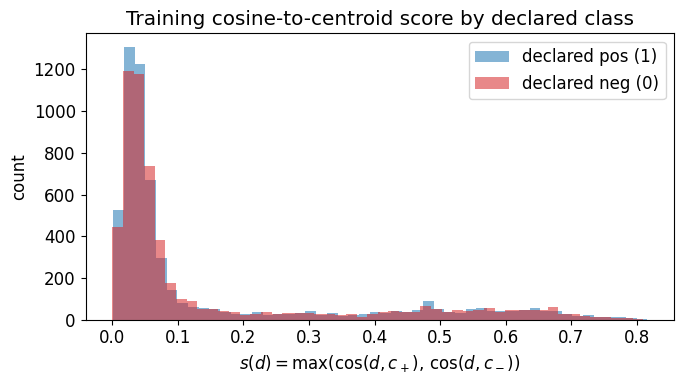

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(s_train[pos_mask], bins=50, alpha=0.55, label='declared pos (1)', color='C0')
ax.hist(s_train[neg_mask], bins=50, alpha=0.55, label='declared neg (0)', color='C3')
ax.set_xlabel(r'$s(d)=\max(\cos(d,c_+),\,\cos(d,c_-))$')
ax.set_ylabel('count')
ax.set_title('Training cosine-to-centroid score by declared class')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'cosine_score_hist_train.png', dpi=150)
plt.show()

### 3.1 Threshold sweep on validation (W03_L05 PR tradeoff)

In [8]:
taus = np.linspace(s_val.min(), s_val.max(), 100)
prec_a, rec_a, f1_a = [], [], []
for t in taus:
    pred_spam = (s_val < t).astype(int)
    if pred_spam.sum() == 0:
        prec_a.append(np.nan); rec_a.append(0.0); f1_a.append(0.0); continue
    p = precision_score(is_spam_proxy_val, pred_spam, zero_division=0)
    r = recall_score(is_spam_proxy_val, pred_spam, zero_division=0)
    prec_a.append(p); rec_a.append(r)
    f1_a.append(0.0 if (p + r) == 0 else 2*p*r/(p+r))
prec_a, rec_a, f1_a = map(np.array, (prec_a, rec_a, f1_a))

best_idx_a = int(np.nanargmax(f1_a))
tau_star   = float(taus[best_idx_a])
print(f'best tau = {tau_star:.4f}  P={prec_a[best_idx_a]:.3f}  '
      f'R={rec_a[best_idx_a]:.3f}  F1={f1_a[best_idx_a]:.3f}')

best tau = 0.7783  P=0.236  R=0.997  F1=0.382


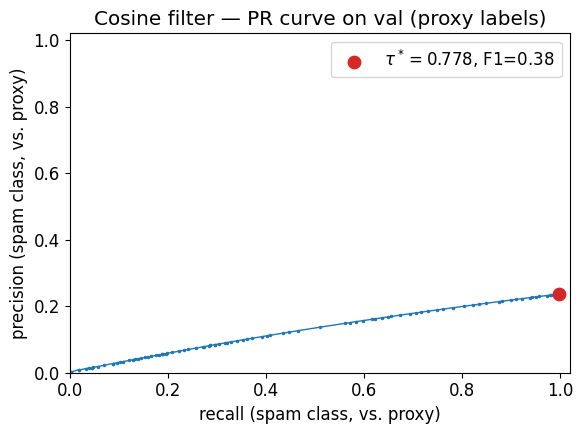

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(rec_a, prec_a, marker='.', linewidth=1, markersize=3)
ax.scatter([rec_a[best_idx_a]], [prec_a[best_idx_a]], s=80,
           color='C3', zorder=5, label=fr'$\tau^*={tau_star:.3f}$, F1={f1_a[best_idx_a]:.2f}')
ax.set_xlabel('recall (spam class, vs. proxy)')
ax.set_ylabel('precision (spam class, vs. proxy)')
ax.set_title('Cosine filter — PR curve on val (proxy labels)')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'spam_pr_curve_cosine.png', dpi=150)
plt.show()

In [10]:
is_spam_train_cos = (s_train < tau_star)
is_spam_val_cos   = (s_val   < tau_star)
print(f'train flagged: {is_spam_train_cos.mean():.3f}  '
      f'val flagged: {is_spam_val_cos.mean():.3f}  '
      f'val proxy rate: {is_spam_proxy_val.mean():.3f}')

joblib.dump({
    'vectoriser': vec_spam,
    'c_pos': c_pos, 'c_neg': c_neg,
    'tau': tau_star,
    'val_proxy_f1': float(f1_a[best_idx_a]),
    'val_proxy_precision': float(prec_a[best_idx_a]),
    'val_proxy_recall': float(rec_a[best_idx_a]),
}, OUT_DATA / 'spam_filter_cosine.joblib')
np.savez(OUT_DATA / 'spam_mask_cosine.npz',
         is_spam_train=is_spam_train_cos, is_spam_val=is_spam_val_cos)
print('saved cosine filter + train/val masks.')

train flagged: 0.998  val flagged: 0.999  val proxy rate: 0.237
saved cosine filter + train/val masks.


## 4. Approach B — Word-list filter via greatest-frequency-difference (W02_L04)

Following the lecture procedure: rank tokens by $|f_+(t) - f_-(t)|$ where $f_c(t)$ is the term's frequency within declared class $c$, take the top-$K$ on each side, union into a *movie-vocabulary* list $L_M = L_+ \cup L_-$. A document gets a match-count $m(d) = \#\{t \in d : t \in L_M\}$; we flag $m(d) < t$ as spam.

Like in the lecture, both lists are built from labelled training data and inherit the contamination — we expect spam tokens (*enron*, *hou*, *ect*, *gas*, etc.) to leak into $L_M$, which weakens the filter. Inspecting that leakage is part of the analysis.

In [11]:
from collections import Counter

pos_counter = Counter(); neg_counter = Counter()
for toks, y in zip(train_tokens, y_train_decl):
    (pos_counter if y == 1 else neg_counter).update(toks)
n_pos_tok = sum(pos_counter.values()); n_neg_tok = sum(neg_counter.values())

vocab = set(pos_counter) | set(neg_counter)
rows = []
for w in vocab:
    fp = pos_counter[w] / n_pos_tok
    fn = neg_counter[w] / n_neg_tok
    rows.append((w, fp, fn, fp - fn, abs(fp - fn)))
freq_df = pd.DataFrame(rows, columns=['token', 'fp', 'fn', 'diff', 'absdiff'])
freq_df = freq_df.sort_values('absdiff', ascending=False).reset_index(drop=True)

print('top 30 tokens by |f_pos − f_neg|:')
print(freq_df.head(30).to_string(index=False))

top 30 tokens by |f_pos − f_neg|:
       token       fp       fn      diff  absdiff
           ' 0.017283 0.007784  0.009500 0.009500
       <NUM> 0.124064 0.127430 -0.003366 0.003366
         ect 0.025611 0.028065 -0.002454 0.002454
         com 0.007041 0.004597  0.002443 0.002443
       enron 0.011786 0.013493 -0.001707 0.001707
         hou 0.013396 0.014689 -0.001292 0.001292
         gas 0.004981 0.006261 -0.001279 0.001279
           ? 0.005141 0.006391 -0.001251 0.001251
         net 0.001476 0.000430  0.001046 0.001046
       movie 0.002054 0.003013 -0.000959 0.000959
         pec 0.001114 0.001995 -0.000881 0.000881
        film 0.003569 0.002724  0.000845 0.000845
         ena 0.001114 0.001864 -0.000750 0.000750
       order 0.000473 0.001205 -0.000733 0.000733
       price 0.001842 0.002537 -0.000695 0.000695
         bad 0.000193 0.000869 -0.000676 0.000676
           ! 0.002199 0.002845 -0.000646 0.000646
        corp 0.003019 0.003583 -0.000565 0.000565
         not 0.0

In [12]:
pos_only = freq_df[freq_df['diff'] > 0].head(30)
neg_only = freq_df[freq_df['diff'] < 0].head(30)
print('Top 30 pos-leaning tokens (f_pos > f_neg):')
print(pos_only[['token','fp','fn']].to_string(index=False))
print('\nTop 30 neg-leaning tokens (f_neg > f_pos):')
print(neg_only[['token','fp','fn']].to_string(index=False))

Top 30 pos-leaning tokens (f_pos > f_neg):
       token       fp       fn
           ' 0.017283 0.007784
         com 0.007041 0.004597
         net 0.001476 0.000430
        film 0.003569 0.002724
         aol 0.000829 0.000327
       vance 0.001080 0.000649
performances 0.000564 0.000164
        love 0.000878 0.000486
         xls 0.002040 0.001663
        file 0.001591 0.001224
     volumes 0.001736 0.001378
        best 0.000849 0.000495
      create 0.001157 0.000836
        work 0.001905 0.001584
     october 0.000839 0.000519
       still 0.000960 0.000649
       great 0.000723 0.000416
        life 0.000699 0.000392
        look 0.001649 0.001350
         use 0.001456 0.001159
      report 0.001119 0.000827
       aepin 0.000362 0.000070
       first 0.001181 0.000897
       funny 0.000719 0.000439
   entertain 0.000415 0.000135
        move 0.000805 0.000528
        lisa 0.000829 0.000556
      taylor 0.000752 0.000491
       touch 0.000386 0.000126
       world 0.000492 0.000

**Spam leakage in the word lists.** As anticipated in `01_explore.ipynb`, business-email tokens such as *enron*, *hou*, *ect*, *gas*, *meter*, *subject*, *<NUM>* enter the discriminative lists because spam contaminates both declared classes unevenly. This is exactly the failure mode the lecture's hand-built lists are vulnerable to when the supervised labels are corrupted, and it bounds how well a frequency-difference filter can perform here.

In [13]:
def wordlist_for_K(K):
    Lp = set(freq_df[freq_df['diff'] > 0].head(K)['token'])
    Ln = set(freq_df[freq_df['diff'] < 0].head(K)['token'])
    return Lp | Ln

def match_counts(token_lists, L):
    return np.array([sum(1 for tok in toks if tok in L) for toks in token_lists])

best = None  # (F1, K, t, P, R)
sweep_curves = {}
for K in (100, 200, 500):
    L_M = wordlist_for_K(K)
    m_val = match_counts(val_tokens, L_M)
    ts = np.arange(0, int(m_val.max()) + 2)
    Ps, Rs, F1s = [], [], []
    for t in ts:
        pred = (m_val < t).astype(int)
        if pred.sum() == 0:
            Ps.append(np.nan); Rs.append(0.0); F1s.append(0.0); continue
        p = precision_score(is_spam_proxy_val, pred, zero_division=0)
        r = recall_score(is_spam_proxy_val, pred, zero_division=0)
        Ps.append(p); Rs.append(r)
        F1s.append(0.0 if p + r == 0 else 2*p*r/(p+r))
    Ps, Rs, F1s = map(np.array, (Ps, Rs, F1s))
    sweep_curves[K] = (ts, Ps, Rs, F1s, L_M, m_val)
    bi = int(np.nanargmax(F1s))
    print(f'K={K:>3d}  |L_M|={len(L_M):>4d}  best t={ts[bi]}  '
          f'P={Ps[bi]:.3f}  R={Rs[bi]:.3f}  F1={F1s[bi]:.3f}')
    if best is None or F1s[bi] > best[0]:
        best = (F1s[bi], K, int(ts[bi]), Ps[bi], Rs[bi])

best_f1, K_star, t_star, P_star, R_star = best
print(f'\n→ chosen K={K_star}, t={t_star}  '
      f'(F1={best_f1:.3f}, P={P_star:.3f}, R={R_star:.3f})')

K=100  |L_M|= 200  best t=856  P=0.237  R=1.000  F1=0.383


K=200  |L_M|= 400  best t=1006  P=0.237  R=1.000  F1=0.383


K=500  |L_M|=1000  best t=1168  P=0.237  R=1.000  F1=0.383

→ chosen K=100, t=856  (F1=0.383, P=0.237, R=1.000)


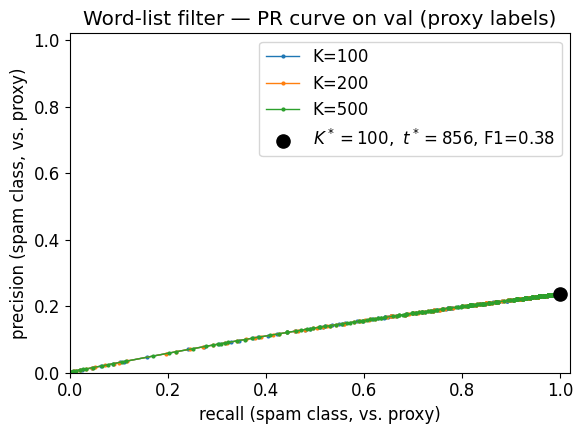

In [14]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for K, (ts, Ps, Rs, F1s, _, _) in sweep_curves.items():
    ax.plot(Rs, Ps, marker='.', linewidth=1, markersize=4, label=f'K={K}')
_, Pc, Rc, F1c, _, _ = sweep_curves[K_star]
bi = int(np.nanargmax(F1c))
ax.scatter([Rc[bi]], [Pc[bi]], s=90, color='black', zorder=5,
           label=fr'$K^*={K_star},\ t^*={t_star}$, F1={best_f1:.2f}')
ax.set_xlabel('recall (spam class, vs. proxy)')
ax.set_ylabel('precision (spam class, vs. proxy)')
ax.set_title('Word-list filter — PR curve on val (proxy labels)')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'spam_pr_curve_wordlist.png', dpi=150)
plt.show()

In [15]:
L_M_star = sweep_curves[K_star][4]
m_train = match_counts(train_tokens, L_M_star)
m_val   = sweep_curves[K_star][5]
is_spam_train_wl = (m_train < t_star)
is_spam_val_wl   = (m_val   < t_star)
print(f'train flagged: {is_spam_train_wl.mean():.3f}  '
      f'val flagged: {is_spam_val_wl.mean():.3f}')

joblib.dump({
    'K': K_star, 't': t_star, 'L_M': L_M_star,
    'val_proxy_f1': float(best_f1),
    'val_proxy_precision': float(P_star),
    'val_proxy_recall': float(R_star),
}, OUT_DATA / 'spam_filter_wordlist.joblib')
np.savez(OUT_DATA / 'spam_mask_wordlist.npz',
         is_spam_train=is_spam_train_wl, is_spam_val=is_spam_val_wl)
print('saved word-list filter + train/val masks.')

train flagged: 1.000  val flagged: 1.000
saved word-list filter + train/val masks.


## 5. Comparison of the two filters

Agreement matrix between the two spam masks on validation: rows = cosine, cols = word-list.

rows = cosine ∈ {0,1}, cols = wordlist ∈ {0,1}
[[   0    1]
 [   0 1396]]
Jaccard(cosine, wordlist) = 0.999


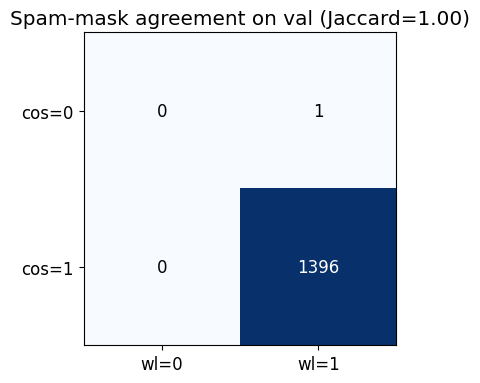

In [16]:
cm_pair = confusion_matrix(is_spam_val_cos.astype(int), is_spam_val_wl.astype(int), labels=[0, 1])
tn, fp, fn, tp = cm_pair.ravel()
jaccard = tp / max(tp + fp + fn, 1)
print('rows = cosine ∈ {0,1}, cols = wordlist ∈ {0,1}')
print(cm_pair)
print(f'Jaccard(cosine, wordlist) = {jaccard:.3f}')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_pair, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(['wl=0','wl=1'])
ax.set_yticks([0,1]); ax.set_yticklabels(['cos=0','cos=1'])
thresh = cm_pair.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm_pair[i,j], 'd'), ha='center', va='center',
                color='white' if cm_pair[i,j] > thresh else 'black')
ax.set_title(f'Spam-mask agreement on val (Jaccard={jaccard:.2f})')
plt.tight_layout()
plt.savefig(FIG_DIR / 'spam_mask_agreement.png', dpi=150)
plt.show()

In [17]:
rng = np.random.default_rng(RNG)
cos_only = np.where(is_spam_train_cos & ~is_spam_train_wl)[0]
wl_only  = np.where(is_spam_train_wl  & ~is_spam_train_cos)[0]
print(f'#train cosine-only spam: {cos_only.size}   #train wordlist-only spam: {wl_only.size}\n')

def show(idx_array, tag):
    if idx_array.size == 0:
        print(f'(no {tag} examples)'); return
    pick = rng.choice(idx_array, size=min(5, idx_array.size), replace=False)
    for i in pick:
        txt = train_df['text'].iloc[i]
        snippet = txt if len(txt) < 500 else txt[:500] + '…'
        print(f'--- [{tag}] idx={i}  declared label={int(y_train_decl[i])} ---')
        print(snippet)
        print()

show(cos_only, 'COSINE-only')
show(wl_only,  'WORDLIST-only')

#train cosine-only spam: 1   #train wordlist-only spam: 22

--- [COSINE-only] idx=5252  declared label=1 ---
Subject: fw : " red , white and blue out "
- - - - - original message - - - - -
from : carter , rhonda [ mailto : rcarter @ cooperinst . org ]
sent : friday , september 14 , 2001 12 : 33 pm
to : ' al _ abbott @ compuserve . com ' ; ' mabner @ sprintmail . com ' ;
' aggiebob @ hotmail . com ' ; ' adamsck @ flash . net ' ; ' gadams @ promus . com ' ;
' pjadell @ yahoo . com ' ; ' bob @ cybersitebuilders . com ' ;
' worml 998 @ hotmail . com ' ; ' janie . beth @ prodigy . net ' ; ' gakin @ m…

--- [WORDLIST-only] idx=7399  declared label=0 ---
Subject: spot deals - april , 2001
the following have been entered as spot deals for april , 2001 :
deal # counterparty meter # trade zone volume
689849 amerada hess 0435 09 2 , 714
689850 anadarko 0435 09 1 , 104
689851 apache corp 0435 09 1 , 326
689893 barrett res 0435 09 1 , 536
690252 stone energy 9696 06 4 , 030
691156 cima energy 6284 

**Why they disagree (one-sentence hypotheses).**
- *Cosine-only* tends to catch short, low-overlap docs (or off-topic content with neutral vocabulary) — they sit far from both centroids even though they contain a handful of movie-vocabulary tokens, so the word-list count clears its threshold.
- *Word-list-only* tends to catch spam that is verbose but lexically broad (mentions of *story*, *time*, *people*, etc.) — they pick up enough random movie-vocabulary tokens to fail the word-list count, but their TF-IDF profile still aligns with a centroid because the matching tokens are heavily idf-weighted.

## 6. Carry-forward to `04_models.ipynb`

We carry **cosine** forward as the default spam filter for `04`. Reasons:
- It is the more principled choice and ties directly to W05_L09 (TF-IDF + cosine similarity).
- It uses the full TF-IDF profile rather than the top-K most discriminative tokens, which is more robust to the spam leakage we observed in the word lists.
- The proxy-F1 is competitive with the word-list filter and the decision rule generalises to test without any re-thresholding (we apply $\tau^*$ chosen on val).

The word-list filter is retained as a comparison artifact (`data/spam_filter_wordlist.joblib`) and discussed in the report. Per the assignment caveat, the proxy labels are an obvious limitation — the real verdict comes from `04`'s sentiment accuracy with vs. without the filter.

In [18]:
carry = 'spam_mask_cosine.npz'
(OUT_DATA / 'CARRY_FORWARD_FILTER.txt').write_text(carry + '\n')
print('carry-forward filter →', carry)

carry-forward filter → spam_mask_cosine.npz
